# Weather RNN

CREDIT FOR PROJECT STRUCTURE: https://github.com/LukeDitria/pytorch_tutorials/blob/main/section12_sequential/solutions/Pytorch2_Autoregressive_RNN.ipynb


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch import optim
from torch.utils.data import DataLoader
from torch.utils.data.dataset import Dataset
import torch.nn.functional as F

from tqdm.notebook import trange, tqdm

import sys
sys.path.insert(0, "../src")
from Dataset import WeatherDataset, FEATURE_COLUMNS


## Data setup

In [4]:
# Path to the CSV file containing the weather dataset
dataset_file = "../data/boston_weather_data_2.csv"

# Date to split the dataset into training and testing sets.
# Data has daily rows from 2024-07-01 through 2026-04-30 (669 days total).
# ~85/15 train/test split lands here:
split_date = pd.to_datetime("2025-11-01")

# Number of days in the input sequence (window length pulled from the dataset)
day_range = 15

# Number of days the model actually looks back on for each prediction step
days_in = 14

# Ensure that the total number of days in the input sequence is larger than days_in
assert day_range > days_in, "The total day range must be larger than the input days"

# Hyperparameters
learning_rate = 1e-4
nepochs = 500
batch_size = 32


In [5]:
dataset_train = WeatherDataset(dataset_file, day_range=day_range, split_date=split_date, train_test="train")
dataset_test = WeatherDataset(dataset_file, day_range=day_range, split_date=split_date, train_test="test")

print(f"Number of training examples: {len(dataset_train)}")
print(f"Number of testing examples: {len(dataset_test)}")
print(f"Features (in order): {FEATURE_COLUMNS}")


Number of training examples: 474
Number of testing examples: 167
Features (in order): ['hum', 'uvi', 'tavg', 'wspd', 'wdir', 'pres', 'prcp']


In [6]:
data_loader_train = DataLoader(dataset=dataset_train, batch_size=batch_size, shuffle=True, drop_last=True)
data_loader_test = DataLoader(dataset=dataset_test, batch_size=batch_size, shuffle=False, drop_last=True)


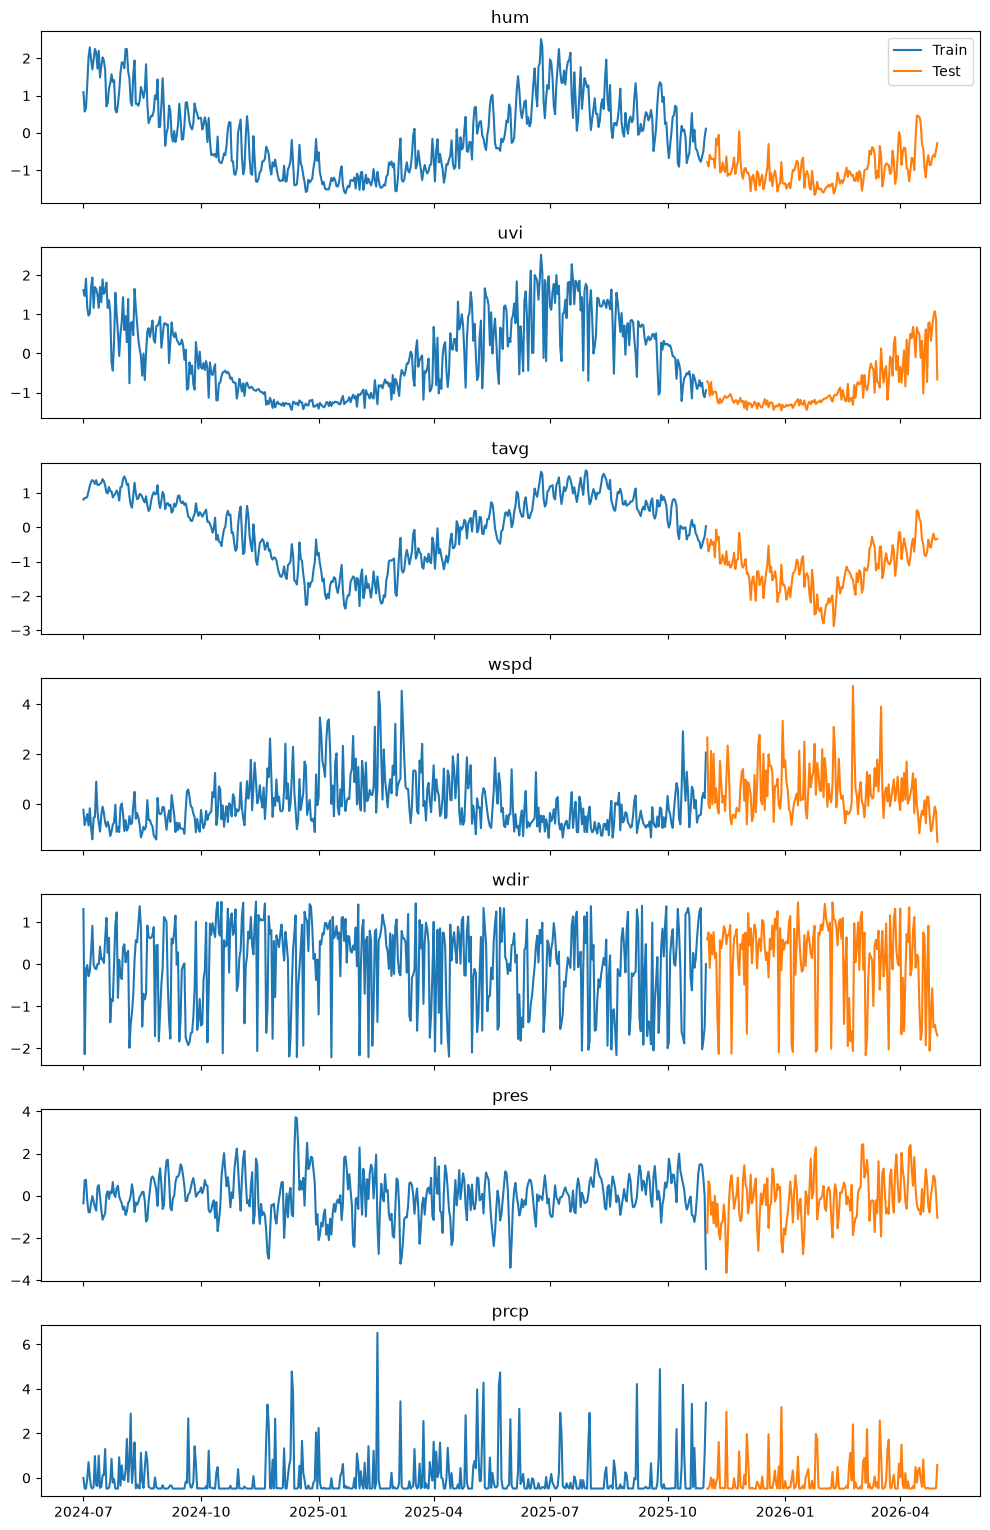

In [7]:
fig, axes = plt.subplots(len(FEATURE_COLUMNS), 1, figsize=(10, 2.2 * len(FEATURE_COLUMNS)), sharex=True)

for i, col in enumerate(FEATURE_COLUMNS):
    axes[i].plot(dataset_train.dates, dataset_train.dataset[col].values)
    axes[i].plot(dataset_test.dates, dataset_test.dataset[col].values)
    axes[i].set_title(col)

axes[0].legend(["Train", "Test"])
plt.tight_layout()
plt.show()


## Create RNN Network

In [8]:
class ResBlockMLP(nn.Module):
    def __init__(self, input_size, output_size):
        super(ResBlockMLP, self).__init__()
        # Layer normalization for the input
        self.norm1 = nn.LayerNorm(input_size)
        # First fully connected layer that reduces the dimensionality by half
        self.fc1 = nn.Linear(input_size, input_size // 2)

        # Layer normalization after the first fully connected layer
        self.norm2 = nn.LayerNorm(input_size // 2)
        # Second fully connected layer that outputs the desired output size
        self.fc2 = nn.Linear(input_size // 2, output_size)

        # Skip connection layer to match the output size
        self.fc3 = nn.Linear(input_size, output_size)

        # Activation function
        self.act = nn.ELU()

    def forward(self, x):
        # Apply normalization and activation function to the input
        x = self.act(self.norm1(x))
        # Compute the skip connection output
        skip = self.fc3(x)

        # Apply the first fully connected layer, normalization, and activation function
        x = self.act(self.norm2(self.fc1(x)))
        # Apply the second fully connected layer
        x = self.fc2(x)

        # Add the skip connection to the output
        return x + skip


class RNN(nn.Module):
    def __init__(self, seq_len, n_features, num_blocks=1, buffer_size=128):
        super(RNN, self).__init__()

        # Flattened length of the input window (days * features per day)
        seq_data_len = seq_len * n_features

        # Input MLP: flattened window -> 128-dim vector
        self.input_mlp = nn.Sequential(
            nn.Linear(seq_data_len, 4 * seq_data_len),
            nn.ELU(),
            nn.Linear(4 * seq_data_len, 128),
            nn.ELU()
        )

        # RNN step: concatenates the input vector with the buffer and feeds it through a linear layer
        self.rnn = nn.Linear(256, 128)

        # Residual blocks
        blocks = [ResBlockMLP(128, 128) for _ in range(num_blocks)]
        self.res_blocks = nn.Sequential(*blocks)

        # Output head: predicts the next day's features
        self.fc_out = nn.Linear(128, n_features)

        # Buffer head: carries information forward to the next time-step
        self.fc_buffer = nn.Linear(128, buffer_size)

        self.act = nn.ELU()

    def forward(self, input_seq, buffer_in):
        # Reshape the input window to a flat vector
        input_seq = input_seq.reshape(input_seq.shape[0], -1)
        input_vec = self.input_mlp(input_seq)

        # Concatenate the previous step's buffer with the input vector
        x_cat = torch.cat((buffer_in, input_vec), 1)

        # Pass through the RNN linear layer
        x = self.rnn(x_cat)

        # Pass through residual blocks
        x = self.act(self.res_blocks(x))

        # Predicted next-day features, and the updated buffer
        return self.fc_out(x), torch.tanh(self.fc_buffer(x))


In [9]:
# Set device to GPU if available, otherwise CPU
device = torch.device(0 if torch.cuda.is_available() else "cpu")

buffer_size = 128
n_features = len(FEATURE_COLUMNS)

weather_rnn = RNN(seq_len=days_in, n_features=n_features, buffer_size=buffer_size).to(device)

optimizer = optim.Adam(weather_rnn.parameters(), lr=learning_rate)
loss_fn = nn.MSELoss()

training_loss_logger = []


In [10]:
num_model_params = 0
for param in weather_rnn.parameters():
    num_model_params += param.flatten().shape[0]

print("-This Model Has %d (Approximately %d Million) Parameters!" % (num_model_params, num_model_params // 1e6))


-This Model Has 172895 (Approximately 0 Million) Parameters!


## Training

In [11]:
for epoch in trange(nepochs, desc="Epochs", leave=False):
    weather_rnn.train()

    for day, month, data_seq in tqdm(data_loader_train, desc="Training", leave=False):
        # Input window: first `days_in` days
        seq_block = data_seq[:, :days_in].to(device)

        # Zero-initialized buffer at the start of each sequence
        buffer = torch.zeros(data_seq.shape[0], buffer_size, device=device)

        loss = 0

        # Roll forward over the remaining days in the window, feeding predictions back in
        for i in range(day_range - days_in):
            target_seq_block = data_seq[:, i + days_in].to(device)

            data_pred, buffer = weather_rnn(seq_block, buffer)

            loss += loss_fn(data_pred, target_seq_block)

            # Slide the window: drop oldest day, append the (detached) prediction
            seq_block = torch.cat((seq_block[:, 1:, :], data_pred.unsqueeze(1).detach()), 1)

        loss /= i + 1

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        training_loss_logger.append(loss.item())


Epochs:   0%|          | 0/500 [00:00<?, ?it/s]

Training:   0%|          | 0/14 [00:00<?, ?it/s]

Training:   0%|          | 0/14 [00:00<?, ?it/s]

Training:   0%|          | 0/14 [00:00<?, ?it/s]

Training:   0%|          | 0/14 [00:00<?, ?it/s]

...

Training:   0%|          | 0/14 [00:00<?, ?it/s]

Training:   0%|          | 0/14 [00:00<?, ?it/s]

Training:   0%|          | 0/14 [00:00<?, ?it/s]

Training:   0%|          | 0/14 [00:00<?, ?it/s]

Training:   0%|          | 0/14 [00:00<?, ?it/s]

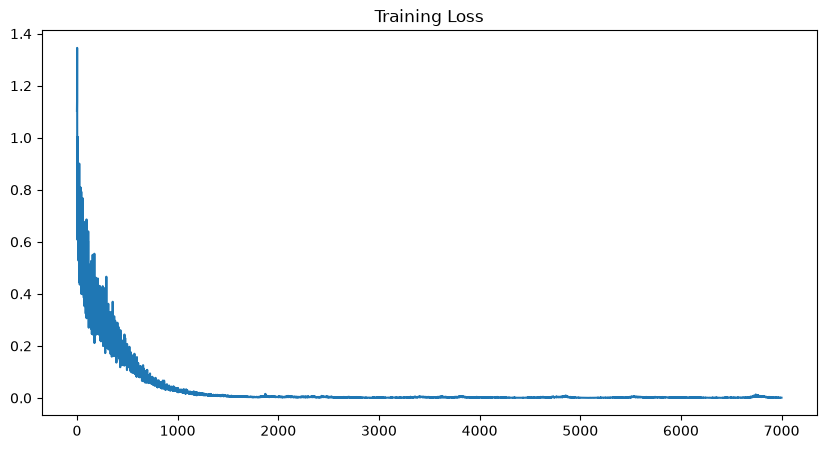

In [12]:
_ = plt.figure(figsize=(10, 5))
_ = plt.plot(training_loss_logger)
_ = plt.title("Training Loss")


## Testing

### Predicting with Feedback

Autoregressive roll-out on the test set: seed with the first `days_in` real days, then keep predicting forward using the model's own previous outputs.


In [13]:
data_tensor = dataset_test.values  # already normalized, [n_days, n_features]

log_predictions = []

weather_rnn.eval()

with torch.no_grad():
    seq_block = data_tensor[:days_in, :].unsqueeze(0).to(device)
    buffer = torch.zeros(seq_block.shape[0], buffer_size, device=device)

    for i in range(data_tensor.shape[0] - days_in):
        data_pred, buffer = weather_rnn(seq_block, buffer)
        log_predictions.append(data_pred.cpu())

        seq_block = torch.cat((seq_block[:, 1:, :], data_pred.unsqueeze(1)), 1)

predictions_cat = torch.cat(log_predictions)

# Unnormalize using the TRAIN mean/std (that's what both datasets were normalized with)
un_norm_predictions = (predictions_cat * dataset_test.std) + dataset_test.mean
un_norm_data = (data_tensor * dataset_test.std) + dataset_test.mean

# Trim the seed days so it lines up with the predictions
un_norm_data = un_norm_data[days_in:]


Test MSE value 1756.0797
  hum   : 12.2876
  uvi   : 0.4773
  tavg  : 65.8433
  wspd  : 1.7671
  wdir  : 12134.7979
  pres  : 1.0641
  prcp  : 76.3217


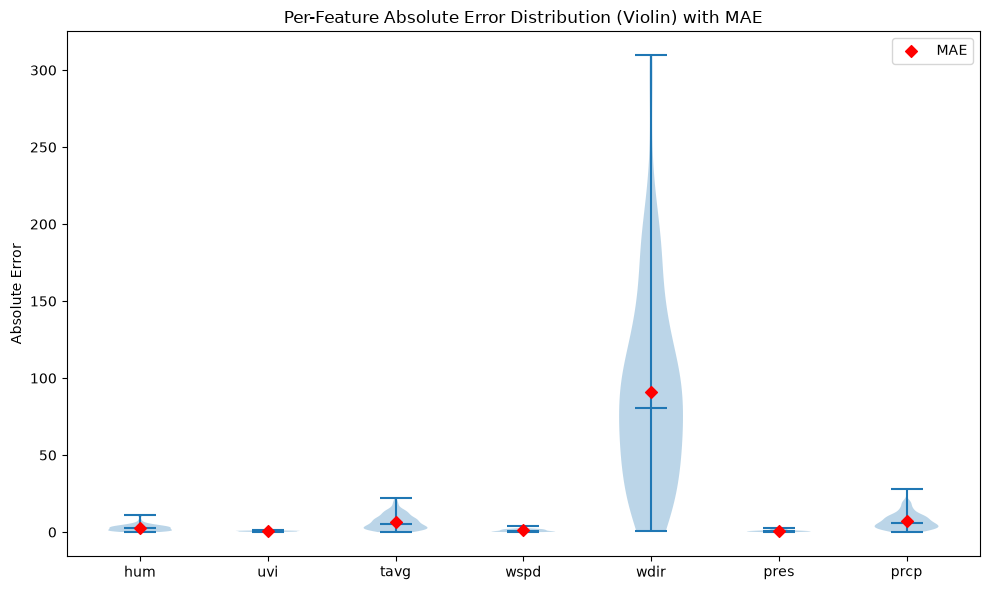

MAE per feature:
  hum   : 2.7972
  uvi   : 0.6130
  tavg  : 6.5275
  wspd  : 1.0728
  wdir  : 90.9612
  pres  : 0.8142
  prcp  : 7.0535


In [14]:
test_mse = (un_norm_data - un_norm_predictions).pow(2).mean().item()
print("Test MSE value %.4f" % test_mse)

# Per-feature MSE is more informative since the features are on very different scales
per_feature_mse = (un_norm_data - un_norm_predictions).pow(2).mean(dim=0)
for name, val in zip(FEATURE_COLUMNS, per_feature_mse.tolist()):
    print(f"  {name:6s}: {val:.4f}")


abs_errors = (un_norm_data - un_norm_predictions).abs()  # [n_days, n_features]
mae_per_feature = abs_errors.mean(dim=0)

fig, ax = plt.subplots(figsize=(10, 6))

violin_data = [abs_errors[:, i].numpy() for i in range(len(FEATURE_COLUMNS))]
positions = np.arange(1, len(FEATURE_COLUMNS) + 1)

parts = ax.violinplot(violin_data, positions=positions, showmeans=False, showmedians=True)

ax.scatter(positions, mae_per_feature.numpy(), color="red", zorder=3, label="MAE", marker="D")

ax.set_xticks(positions)
ax.set_xticklabels(FEATURE_COLUMNS)
ax.set_ylabel("Absolute Error")
ax.set_title("Per-Feature Absolute Error Distribution (Violin) with MAE")
ax.legend()
plt.tight_layout()
plt.show()

print("MAE per feature:")
for name, val in zip(FEATURE_COLUMNS, mae_per_feature.tolist()):
    print(f"  {name:6s}: {val:.4f}")

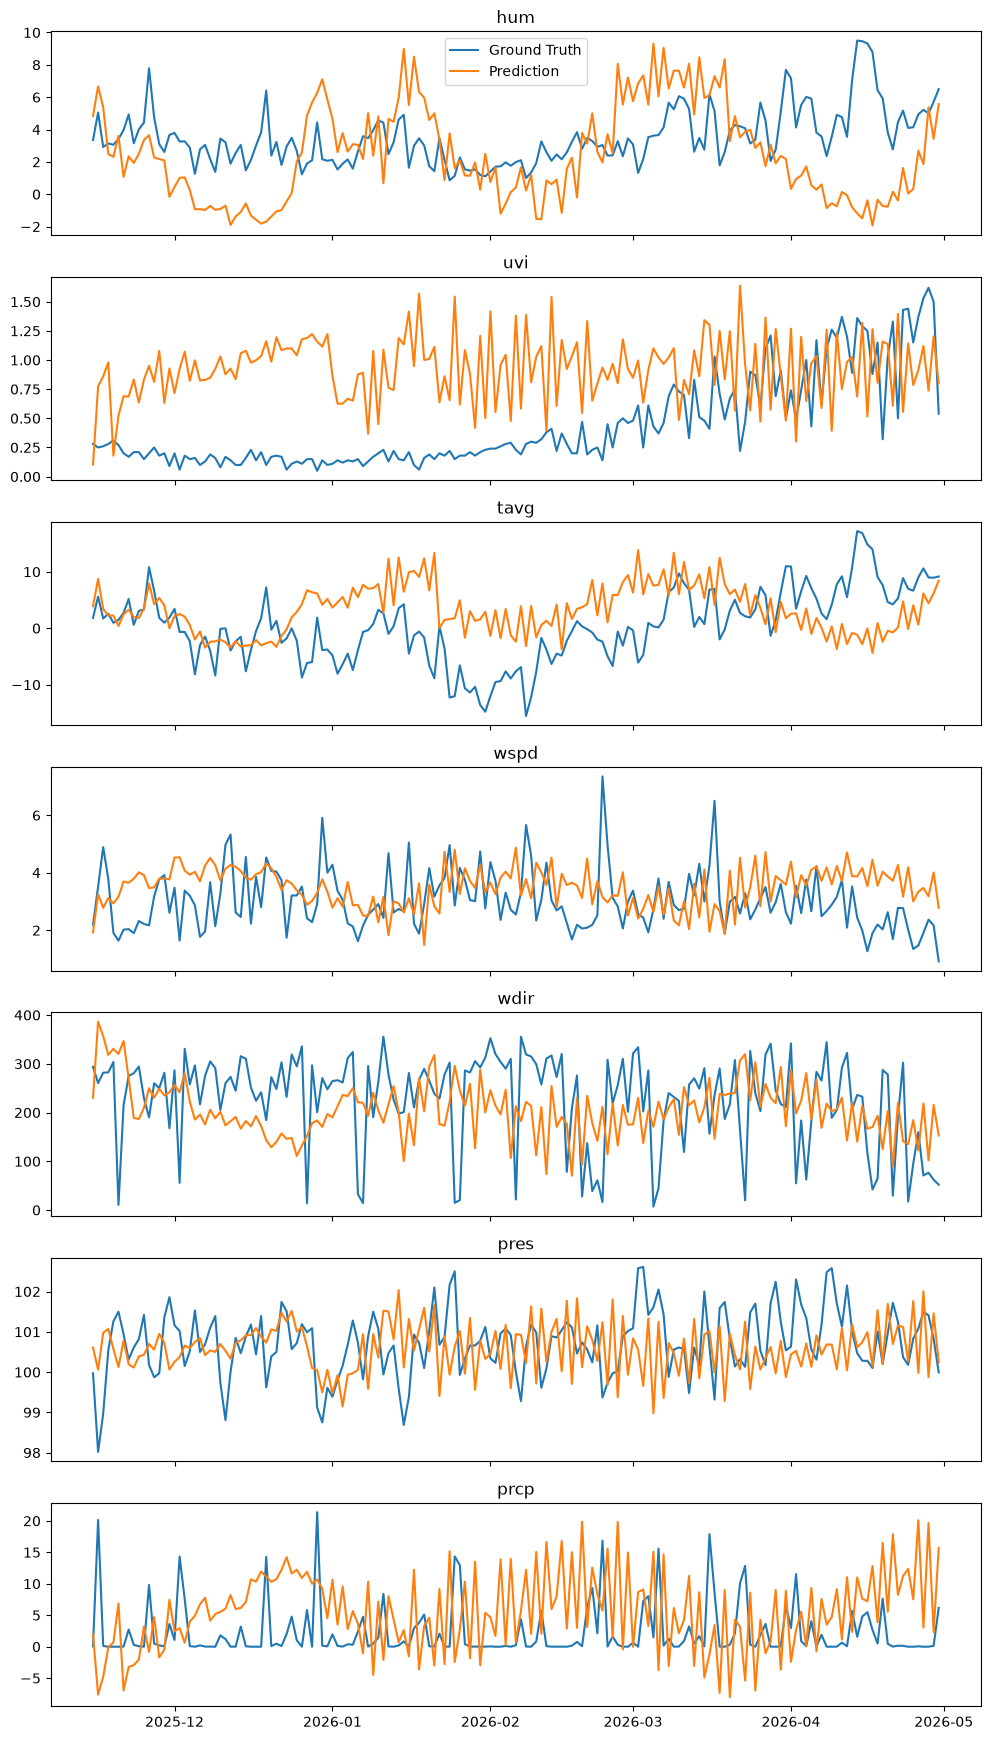

In [15]:
fig, axes = plt.subplots(len(FEATURE_COLUMNS), 1, figsize=(10, 2.5 * len(FEATURE_COLUMNS)), sharex=True)

plot_dates = dataset_test.dates[days_in:]

for i, col in enumerate(FEATURE_COLUMNS):
    axes[i].plot(plot_dates, un_norm_data[:, i])
    axes[i].plot(plot_dates, un_norm_predictions[:, i])
    axes[i].set_title(col)

axes[0].legend(["Ground Truth", "Prediction"])
plt.tight_layout()
plt.show()


### Using Ground Truth First

Predicts the first 30 time steps grounded in real data (teacher forcing), then switches to the model's own predictions for the rest - gives the model more real context before it has to rely on itself.


In [16]:
# # Uncomment to use!
# log_predictions = []
# weather_rnn.eval()
# buffer = torch.zeros(1, buffer_size, device=device)
#
# for i in range(30):
#     seq_block = data_tensor[i:(i + days_in), :].unsqueeze(0).to(device)
#     data_pred, buffer = weather_rnn(seq_block, buffer)
#     log_predictions.append(data_pred.cpu())
#
# for j in range(data_tensor.shape[0] - days_in - 30):
#     seq_block = torch.cat((seq_block[:, 1:, :], data_pred.unsqueeze(1)), 1)
#     data_pred, buffer = weather_rnn(seq_block, buffer)
#     log_predictions.append(data_pred.cpu())
#
# predictions_cat = torch.cat(log_predictions)
# un_norm_predictions = (predictions_cat * dataset_test.std) + dataset_test.mean
# un_norm_data = (data_tensor * dataset_test.std) + dataset_test.mean
# un_norm_data = un_norm_data[days_in:]
